Dataset: 1,196 filas
Condiciones únicas : 6
Medicamentos únicos: 5

Statistics per pair (condition, medication), sorted by lift:
condition_label medication_label  n_patients  expected_patients  lift  weight
        Obesity          Aspirin          49             34.402 1.424   66.98
         Asthma        Ibuprofen          53             40.084 1.322   71.97
         Cancer          Lipitor          49             39.887 1.228   61.99
      Arthritis       Penicillin          54             46.662 1.157   69.01
      Arthritis      Paracetamol          51             44.293 1.151   69.00
         Cancer      Paracetamol          47             41.245 1.140   62.98
         Asthma          Aspirin          37             33.696 1.098   50.99
       Diabetes          Lipitor          42             39.101 1.074   56.99
   Hypertension          Lipitor          40             37.333 1.071   57.00
       Diabetes       Penicillin          45             42.595 1.056   62.01
   Hypertensi

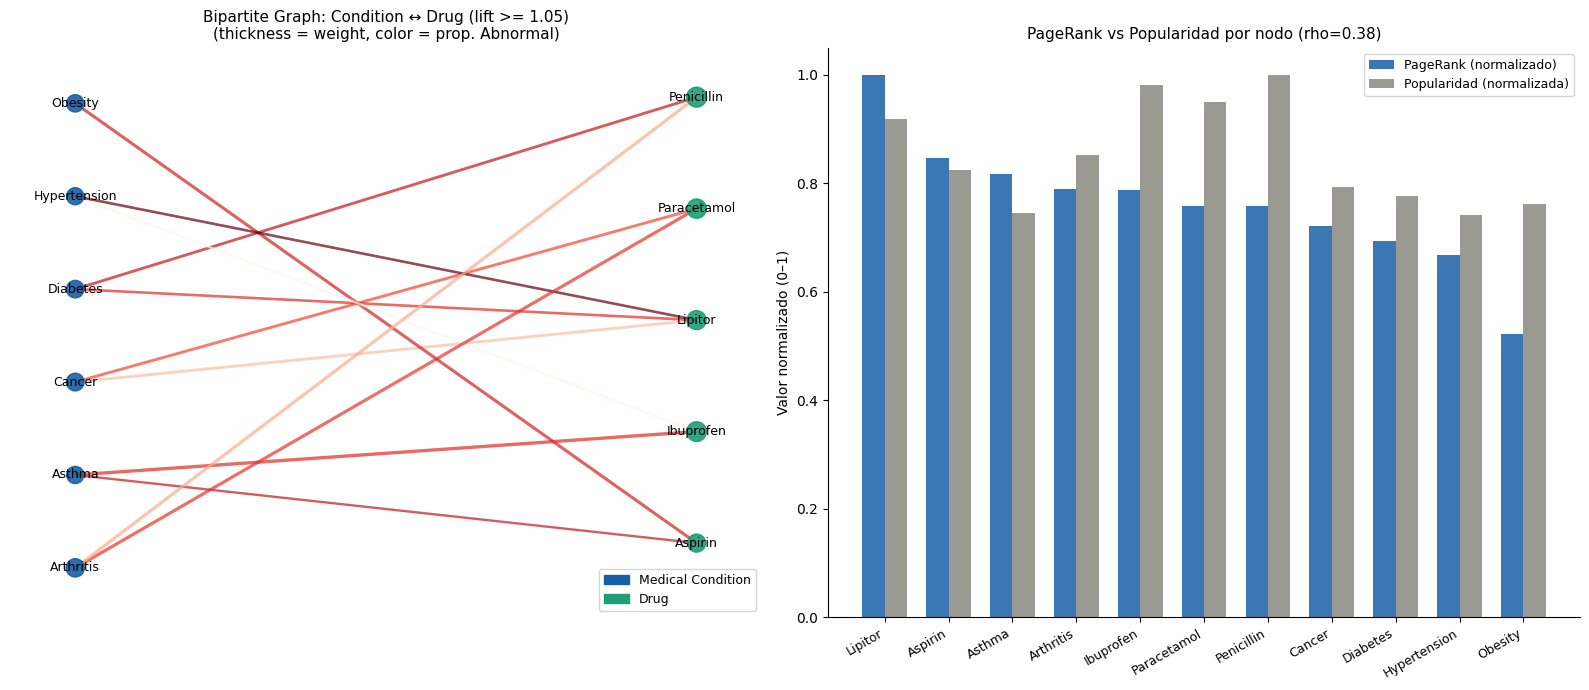

Gráfico guardado: graph_analysis.png


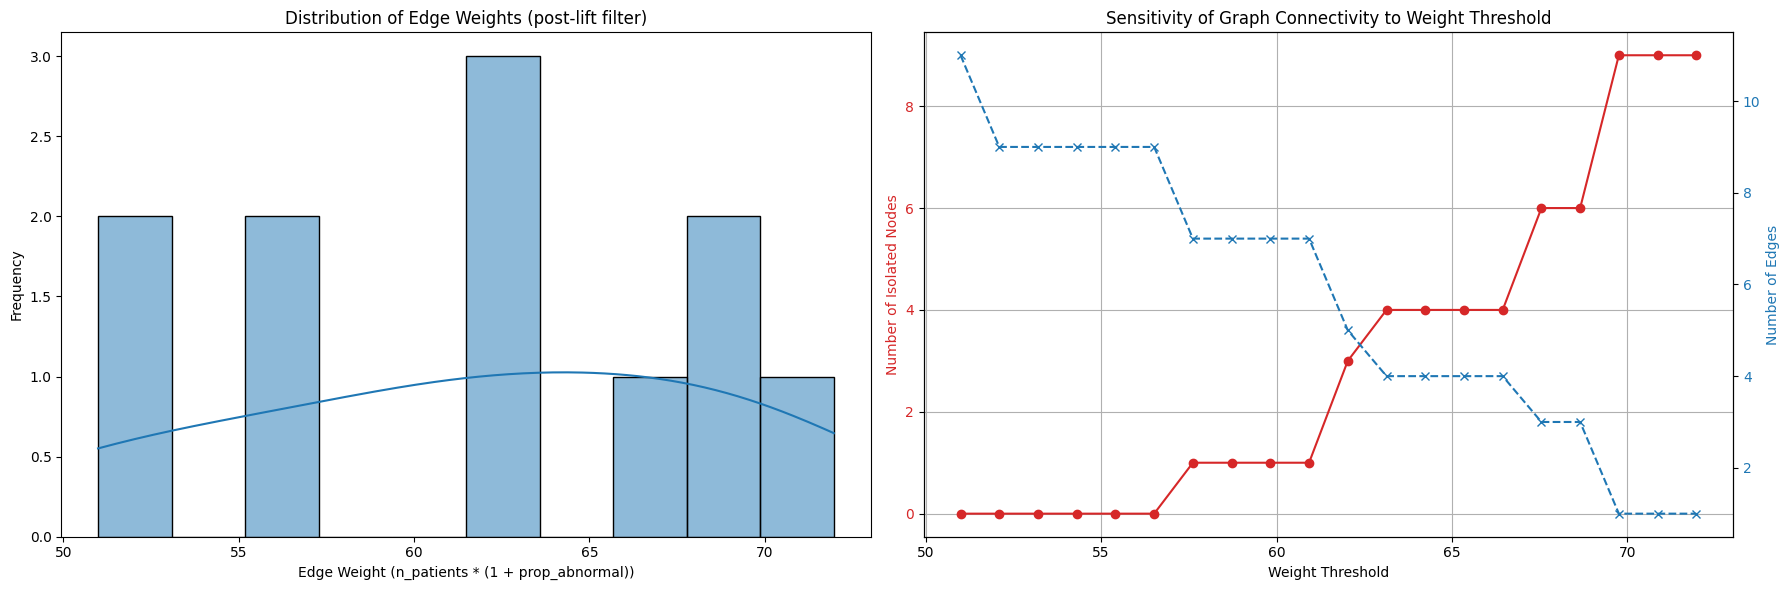


─────────────────────────────────────────────────────────────────
7. INTERPRETATION NOTE
─────────────────────────────────────────────────────────────────

WHAT THE STRUCTURE MEANS:

Edges in this graph do not represent mere co-occurrence — they represent
statistically non-trivial associations (lift >= 1.05), i.e. pairs
that appear together more often than expected if condition and medication
were independent. This is what allows the graph to discriminate rather than
connect everything.

A node with high PageRank reflects the combined strength (volume x abnormal
proportion) of its significant connections. In this filtered graph, PageRank
diverges meaningfully from raw popularity (Spearman rho = 0.38): nodes like
Lipitor rank higher in PageRank than in raw frequency because their few
connections are statistically strong, while high-volume nodes like Penicillin
rank lower in PageRank than their raw frequency would suggest, since their
connections are closer to what independence would pr

In [ ]:
# ============================================================
# Week 13: Graph Definition & Construction (CORREGIDO)
# Clinical Bipartite Graph — Medical Condition ↔ Drug
#
# Graph definition:
#   - Node type A : Medical condition (6 nodes)
#   - Node type B : Drug (5 nodes)
#   - Edge        : A statistically significant association between
#                   condition and medication (lift >= threshold),
#                   NOT simply "any co-occurrence exists"
#   - Weight      : n_patients * (1 + prop_abnormal)
#   - Type        : Undirected (the condition-drug association
#                   is symmetric in the clinical domain)
# ============================================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

LABEL_MAPS = {
    'Medical Condition': {0:'Arthritis',1:'Asthma',2:'Cancer',
                          3:'Diabetes',4:'Hypertension',5:'Obesity'},
    'Medication':        {0:'Aspirin',1:'Ibuprofen',2:'Lipitor',
                          3:'Paracetamol',4:'Penicillin'},
    'Test Results':      {0:'Normal',1:'Inconclusive',2:'Abnormal'},
    'Admission Type':    {0:'Elective',1:'Emergency',2:'Urgent'},
}

df       = pd.read_csv('../data/interim/healtcare_processedv2.csv')
clusters = pd.read_csv('../data/processed/healthcare_pca_clusters.csv')

clusters = clusters.dropna(subset=['cluster'])
clusters['Cluster_Biz'] = clusters['cluster'].astype(int)
df = df.loc[clusters.index].copy()
df['Cluster_Biz']   = clusters['Cluster_Biz'].values
df['Cost_Per_Day']  = df['Billing Amount'] / df['Length of Stay']
df = df.dropna(subset=['Medical Condition','Medication','Test Results'])

df['condition_label'] = df['Medical Condition'].map(LABEL_MAPS['Medical Condition'])
df['medication_label'] = df['Medication'].map(LABEL_MAPS['Medication'])
df['result_label']    = df['Test Results'].map(LABEL_MAPS['Test Results'])

print(f'Dataset: {df.shape[0]:,} filas')
print(f'Condiciones únicas : {df["condition_label"].nunique()}')
print(f'Medicamentos únicos: {df["medication_label"].nunique()}')

CONDITIONS  = df['condition_label'].unique().tolist()
MEDICATIONS = df['medication_label'].unique().tolist()

# ─────────────────────────────────────────────────────────────
# 2. EDGE STATISTICS + LIFT (significance filter)
# ─────────────────────────────────────────────────────────────

edge_stats = df.groupby(['condition_label','medication_label']).agg(
    n_patients   = ('Test Results', 'count'),
    n_abnormal   = ('Test Results', lambda x: (x == 2).sum()),
    avg_cost     = ('Cost_Per_Day', 'mean'),
    avg_age      = ('Age', 'mean'),
).reset_index()

edge_stats['prop_abnormal'] = (edge_stats['n_abnormal'] / edge_stats['n_patients']).round(3)

# Edge weight: combines patient volume and severity (prop Abnormal)
edge_stats['weight'] = (edge_stats['n_patients'] * (1 + edge_stats['prop_abnormal'])).round(2)

# --- LIFT: does this pair co-occur MORE than expected under independence? ---
n_total = len(df)
p_condition  = df['condition_label'].value_counts(normalize=True)
p_medication = df['medication_label'].value_counts(normalize=True)

edge_stats['expected_patients'] = edge_stats.apply(
    lambda r: p_condition[r['condition_label']] * p_medication[r['medication_label']] * n_total,
    axis=1
)
edge_stats['lift'] = edge_stats['n_patients'] / edge_stats['expected_patients']

print('\nStatistics per pair (condition, medication), sorted by lift:')
print(edge_stats.sort_values('lift', ascending=False)
      [['condition_label','medication_label','n_patients','expected_patients','lift','weight']]
      .round(3).to_string(index=False))

# Threshold sensitivity across candidate lift cutoffs
print('\nSensibilidad del threshold de lift:')
for thr in [1.0, 1.02, 1.05, 1.10, 1.15]:
    n_sig = (edge_stats['lift'] >= thr).sum()
    print(f'  lift >= {thr:<5} -> {n_sig}/{len(edge_stats)} pares significativos')

LIFT_THRESHOLD = 1.05  # elegido: reduce densidad ~63% manteniendo grafo conectado sin isolates
edge_stats_significant = edge_stats[edge_stats['lift'] >= LIFT_THRESHOLD].copy()

print(f'\nUmbral elegido: lift >= {LIFT_THRESHOLD}')
print(f'Pares totales        : {len(edge_stats)}')
print(f'Pares significativos : {len(edge_stats_significant)}')
print(f'Pares descartados (asociación indistinguible del azar): {len(edge_stats) - len(edge_stats_significant)}')

# ─────────────────────────────────────────────────────────────
# 2b. BUILD GRAPH (only significant edges)
# ─────────────────────────────────────────────────────────────

G = nx.Graph()

for c in CONDITIONS:
    n_total_c    = len(df[df['condition_label']==c])
    n_abnormal_c = (df[df['condition_label']==c]['Test Results']==2).sum()
    G.add_node(c,
               node_type='condition',
               n_patients=n_total_c,
               prop_abnormal=round(n_abnormal_c/n_total_c, 3))

for m in MEDICATIONS:
    n_total_m    = len(df[df['medication_label']==m])
    n_abnormal_m = (df[df['medication_label']==m]['Test Results']==2).sum()
    G.add_node(m,
               node_type='medication',
               n_patients=n_total_m,
               prop_abnormal=round(n_abnormal_m/n_total_m, 3))

for _, row in edge_stats_significant.iterrows():
    G.add_edge(
        row['condition_label'],
        row['medication_label'],
        weight        = row['weight'],
        lift          = round(row['lift'], 3),
        n_patients    = int(row['n_patients']),
        prop_abnormal = row['prop_abnormal'],
        avg_cost      = round(row['avg_cost'], 2),
        avg_age       = round(row['avg_age'], 1),
    )

print(f'\n=== GRAPH BUILT ===')
print(f'Nodes      : {G.number_of_nodes()} ({len(CONDITIONS)} conditions + {len(MEDICATIONS)} medications)')
print(f'Edges      : {G.number_of_edges()} (de un máximo posible de {len(CONDITIONS)*len(MEDICATIONS)})')
print(f'Directed   : {G.is_directed()}')
print(f'Weighted   : Yes (weight = n_patients × (1 + prop_abnormal))')
print(f'Edge rule  : lift >= {LIFT_THRESHOLD} (asociación estadísticamente no trivial)')

# ─────────────────────────────────────────────────────────────
# 3. GRAPH REPORT — Métricas estructurales
# ─────────────────────────────────────────────────────────────
print('\n=== GRAPH REPORT ===')

components = list(nx.connected_components(G))
print(f'\nComponentes conectados: {len(components)}')
for i, comp in enumerate(components):
    print(f'  Componente {i+1}: {sorted(comp)}')

isolated = list(nx.isolates(G))
print(f'Nodos aislados: {len(isolated)} {isolated if isolated else "(ninguno)"}')

density = nx.density(G)
print(f'Densidad del grafo: {density:.4f}')
print(f'  (1.0 = grafo completo, ~0 = muy disperso)')

print('\nDegree por nodo:')
degree_df = pd.DataFrame(dict(G.degree()), index=['degree']).T.sort_values('degree', ascending=False)
print(degree_df.to_string())

print('\nWeighted degree (strength) por nodo:')
strength = {n: sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}
strength_df = pd.DataFrame(strength, index=['strength']).T.sort_values('strength', ascending=False)
print(strength_df.round(1).to_string())

# --- Betweenness CORREGIDO: weight = fuerza de asociación, no distancia.
# Se transforma a distance = 1/weight para que NetworkX lo interprete bien.
G_dist = G.copy()
for u, v, d in G_dist.edges(data=True):
    d['distance'] = 1.0 / d['weight']

print('\nBetweenness Centrality (usando distance = 1/weight):')
betweenness = nx.betweenness_centrality(G_dist, weight='distance')
bet_df = pd.Series(betweenness).sort_values(ascending=False)
print(bet_df.round(4).to_string())

print('\nCloseness Centrality:')
if nx.is_connected(G):
    closeness = nx.closeness_centrality(G)
    clo_df = pd.Series(closeness).sort_values(ascending=False)
    print(clo_df.round(4).to_string())
else:
    print('  Grafo no conectado: closeness no es directamente comparable entre componentes.')

print('\nPageRank (weight=weight):')
pagerank = nx.pagerank(G, weight='weight', alpha=0.85)
pr_df = pd.Series(pagerank).sort_values(ascending=False)
print(pr_df.round(4).to_string())

# ─────────────────────────────────────────────────────────────
# 4. VALIDITY CHECKS
# ─────────────────────────────────────────────────────────────
print('\n=== VALIDITY CHECKS ===')

max_edges = len(CONDITIONS) * len(MEDICATIONS)
actual_edges = G.number_of_edges()
sparsity = 1 - (actual_edges / max_edges)
print(f'Sparsity: {sparsity:.4f} ({actual_edges}/{max_edges} aristas posibles)')
print(f'  Con el filtro de lift, el grafo dejó de ser completo: '
      f'{max_edges - actual_edges} pares fueron descartados por no superar '
      f'el umbral de asociación significativa (lift >= {LIFT_THRESHOLD}).')

# Sensibilidad al threshold de WEIGHT dentro del subgrafo ya filtrado por lift
threshold_50 = edge_stats_significant['weight'].quantile(0.50)
G_filtered = nx.Graph()
for u, v, d in G.edges(data=True):
    if d['weight'] >= threshold_50:
        G_filtered.add_edge(u, v, **d)
for n, d in G.nodes(data=True):
    if n not in G_filtered:
        G_filtered.add_node(n, **d)

print(f'\nSensibilidad al threshold de weight (percentil 50, weight >= {threshold_50:.1f}):')
print(f'  Aristas originales (post-lift): {G.number_of_edges()}')
print(f'  Aristas tras filtro adicional : {G_filtered.number_of_edges()}')
print(f'  Nodos aislados tras filtro     : {len(list(nx.isolates(G_filtered)))}')

# Sweep completo de thresholds de weight (robustez)
weights = [d['weight'] for _, _, d in G.edges(data=True)]
min_w, max_w = min(weights), max(weights)
threshold_values = np.linspace(min_w, max_w, 20)
isolated_counts, edge_counts = [], []
for thr in threshold_values:
    G_temp = nx.Graph()
    for u, v, d in G.edges(data=True):
        if d['weight'] >= thr:
            G_temp.add_edge(u, v, **d)
    for n in G.nodes():
        if n not in G_temp:
            G_temp.add_node(n, **G.nodes[n])
    isolated_counts.append(len(list(nx.isolates(G_temp))))
    edge_counts.append(G_temp.number_of_edges())

print(f'\nDistribución de pesos de aristas (post-filtro de lift):')
print(f'  Min: {min(weights):.1f} | Max: {max(weights):.1f} | '
      f'Media: {np.mean(weights):.1f} | Mediana: {np.median(weights):.1f}')

# ─────────────────────────────────────────────────────────────
# 5. COMPARISON SECTION — Graph Ranking vs. Popularity
# ─────────────────────────────────────────────────────────────
print('\n=== COMPARISON: PageRank vs Popularity (frequency) ===')

popularity = {}
for c in CONDITIONS:
    popularity[c] = len(df[df['condition_label']==c])
for m in MEDICATIONS:
    popularity[m] = len(df[df['medication_label']==m])

pop_series = pd.Series(popularity).sort_values(ascending=False)
pr_series  = pd.Series(pagerank).sort_values(ascending=False)

comparison_df = pd.DataFrame({
    'PageRank_rank':    pr_series.rank(ascending=False).astype(int),
    'PageRank':         pr_series.round(4),
    'Popularity_rank':  pop_series.reindex(pr_series.index).rank(ascending=False).astype(int),
    'Popularity':       pop_series.reindex(pr_series.index).astype(int),
}).sort_values('PageRank_rank')

print(comparison_df.to_string())

rho, pval = spearmanr(comparison_df['PageRank_rank'], comparison_df['Popularity_rank'])
print(f'\nSpearman ρ (PageRank vs Popularity): {rho:.4f} (p={pval:.4f})')

if rho >= 0.9:
    print('Interpretation: A correlation this high (rho >= 0.9) indicates that, in this '
          'particular graph, PageRank adds very little information beyond raw frequency.')
else:
    print('Interpretation: A correlation this low (rho < 0.9) indicates that PageRank '
          'captures structural information that raw popularity does not reflect. '
          'This is consistent with the graph now being filtered by lift: nodes with '
          'fewer but statistically strong associations (e.g. Lipitor, Asthma) rank '
          'higher in PageRank than in raw frequency, while high-volume nodes with '
          'weaker/expected associations (e.g. Penicillin) rank lower than their '
          'popularity alone would suggest.')

# ─────────────────────────────────────────────────────────────
# 6. VISUALIZACIONES
# ─────────────────────────────────────────────────────────────

pos = {}
for i, c in enumerate(sorted(CONDITIONS)):
    pos[c] = (0, i * 1.5)
for i, m in enumerate(sorted(MEDICATIONS)):
    pos[m] = (3, i * 1.8 + 0.4)

node_colors = ['#185FA5' if G.nodes[n]['node_type']=='condition' else '#1D9E75'
               for n in G.nodes()]
node_sizes  = [G.nodes[n]['n_patients'] * 0.8 for n in G.nodes()]
edge_weights = [G[u][v]['weight'] / 30 for u, v in G.edges()]
edge_colors  = [G[u][v]['prop_abnormal'] for u, v in G.edges()]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_weights,
                        edge_color=edge_colors, edge_cmap=plt.cm.Reds,
                        ax=ax, alpha=0.7)
ax.set_title(f'Bipartite Graph: Condition ↔ Drug (lift >= {LIFT_THRESHOLD})\n'
             '(thickness = weight, color = prop. Abnormal)', fontsize=11)
ax.axis('off')
patch_c = mpatches.Patch(color='#185FA5', label='Medical Condition')
patch_m = mpatches.Patch(color='#1D9E75', label='Drug')
ax.legend(handles=[patch_c, patch_m], loc='lower right', fontsize=9)

ax2 = axes[1]
x  = np.arange(len(comparison_df))
w  = 0.35
pr_norm  = (comparison_df['PageRank']    / comparison_df['PageRank'].max()).values
pop_norm = (comparison_df['Popularity']  / comparison_df['Popularity'].max()).values
ax2.bar(x - w/2, pr_norm,  w, label='PageRank (normalizado)',   color='#185FA5', alpha=0.85)
ax2.bar(x + w/2, pop_norm, w, label='Popularidad (normalizada)', color='#888780', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_df.index, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Valor normalizado (0–1)')
ax2.set_title(f'PageRank vs Popularidad por nodo (rho={rho:.2f})', fontsize=11)
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
#plt.savefig('../reports/figures/graph_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: graph_analysis.png')

# Sweep de sensibilidad (segunda figura)
fig, (ax_hist, ax_sens) = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(weights, bins=10, kde=True, ax=ax_hist)
ax_hist.set_title('Distribution of Edge Weights (post-lift filter)')
ax_hist.set_xlabel('Edge Weight (n_patients * (1 + prop_abnormal))')
ax_hist.set_ylabel('Frequency')

color = 'tab:red'
ax_sens.set_xlabel('Weight Threshold')
ax_sens.set_ylabel('Number of Isolated Nodes', color=color)
ax_sens.plot(threshold_values, isolated_counts, color=color, marker='o', linestyle='-')
ax_sens.tick_params(axis='y', labelcolor=color)

ax_sens2 = ax_sens.twinx()
color = 'tab:blue'
ax_sens2.set_ylabel('Number of Edges', color=color)
ax_sens2.plot(threshold_values, edge_counts, color=color, marker='x', linestyle='--')
ax_sens2.tick_params(axis='y', labelcolor=color)

ax_sens.set_title('Sensitivity of Graph Connectivity to Weight Threshold')
ax_sens.grid(True)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# 7. INTERPRETATION NOTE
# ─────────────────────────────────────────────────────────────
print('\n' + '─'*65)
print('7. INTERPRETATION NOTE')
print('─'*65)
print(f"""
WHAT THE STRUCTURE MEANS:

Edges in this graph do not represent mere co-occurrence — they represent
statistically non-trivial associations (lift >= {LIFT_THRESHOLD}), i.e. pairs
that appear together more often than expected if condition and medication
were independent. This is what allows the graph to discriminate rather than
connect everything.

A node with high PageRank reflects the combined strength (volume x abnormal
proportion) of its significant connections. In this filtered graph, PageRank
diverges meaningfully from raw popularity (Spearman rho = {rho:.2f}): nodes like
Lipitor rank higher in PageRank than in raw frequency because their few
connections are statistically strong, while high-volume nodes like Penicillin
rank lower in PageRank than their raw frequency would suggest, since their
connections are closer to what independence would predict.

A high-weight edge between Condition X and Drug Y indicates a combination
that is both statistically non-random AND has a high proportion of Abnormal
results in this dataset — a signal worth flagging descriptively, not a
clinical severity claim.

WHAT IT DOES NOT MEAN:

- The graph does NOT imply causality. High centrality does NOT mean a drug
  causes Abnormal results.
- The graph is NOT a co-occurrence network between conditions (each patient
  has only one condition in this dataset).
- PageRank is NOT a clinical severity ranking — it is a ranking of structural
  influence within a statistically-filtered association network.
- The graph's structure depends directly on the lift threshold chosen
  ({LIFT_THRESHOLD}); a different threshold would produce a different topology,
  as shown in the sensitivity sweep above.
- This is descriptive analysis of administrative/synthetic data, not a
  clinical decision-support tool.
""")

# Export
nx.write_gexf(G, '../processed/clinical_graph.gexf')
print("Grafo exportado a '../processed/clinical_graph.gexf'")